# RBOB MM — Lead/Lag Analysis with Prices (release date join)

RBOB positioning is CFTC-only (NYMEX + ICE Energy Div). 3 flat price contracts
(from cot-ingest/docs/gasoline_cot_mapping.md).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Load RBOB COT

In [2]:
CFTC_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'
cftc = pd.read_csv(CFTC_PATH, low_memory=False)

# All RBOB flat price codes (from cot-ingest/docs/gasoline_cot_mapping.md)
RBOB_CODES = [
    '111659',  # GASOLINE BLENDSTOCK (RBOB) — benchmark
    '11165J',  # RBOB GASOLINE FINANCIAL
    '111416',  # RBOB GASOLINE 1ST LINE (ICE Energy Div)
]

rb_raw = cftc[cftc['cftc_contract_market_code'].isin(RBOB_CODES)].copy()
rb_raw['as_of_date'] = pd.to_datetime(rb_raw['report_date_as_yyyy_mm_dd'])
_SUM_COLS = ['open_interest_all', 'm_money_positions_long_all', 'm_money_positions_short_all']
for c in _SUM_COLS:
    rb_raw[c] = pd.to_numeric(rb_raw[c], errors='coerce')

rbob = rb_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()
rbob['mm_net'] = rbob['m_money_positions_long_all'] - rbob['m_money_positions_short_all']
rbob['mm_net_oi'] = rbob['mm_net'] / rbob['open_interest_all'] * 100
days_ahead = (4 - rbob['as_of_date'].dt.dayofweek) % 7
rbob['release_date'] = rbob['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
rbob.sort_values('as_of_date', inplace=True)
rbob.reset_index(drop=True, inplace=True)

print(f'RBOB rows: {len(rbob)}')
print(f'Range: {rbob["as_of_date"].min().date()} -> {rbob["as_of_date"].max().date()}')


RBOB rows: 1033
Range: 2006-06-13 -> 2026-03-24


## 2. Load prices and join

In [3]:
prices = pd.read_csv('../../../../cache/preprocessed_data/rbob_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)

prices_renamed = prices.rename(columns={'tradeDate': 'release_date'})
df = rbob.merge(prices_renamed, on='release_date', how='inner')
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)
df['mm_net_chg']    = df['mm_net'].diff()
df['mm_net_oi_chg'] = df['mm_net_oi'].diff()
df['price_ret']     = df['F1_RolledPrice'].pct_change() * 100
df.dropna(subset=['mm_net_chg', 'price_ret'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Joined rows: {len(df)}')
print(f'Range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')


Joined rows: 820
Range: 2010-01-12 -> 2026-03-24


## 3. Contemporaneous correlation

In [4]:
rho, p = sp_stats.spearmanr(df['mm_net_chg'], df['price_ret'])
rho_oi, p_oi = sp_stats.spearmanr(df['mm_net_oi_chg'], df['price_ret'])
print('Contemporaneous (same week):')
print(f'  MM net change vs price return:    rho = {rho:+.3f}  (p = {p:.1e})')
print(f'  MM net/OI change vs price return: rho = {rho_oi:+.3f}  (p = {p_oi:.1e})')


Contemporaneous (same week):
  MM net change vs price return:    rho = -0.066  (p = 5.9e-02)
  MM net/OI change vs price return: rho = -0.045  (p = 2.0e-01)


## 4. Cross-correlation function (Friday-Friday)

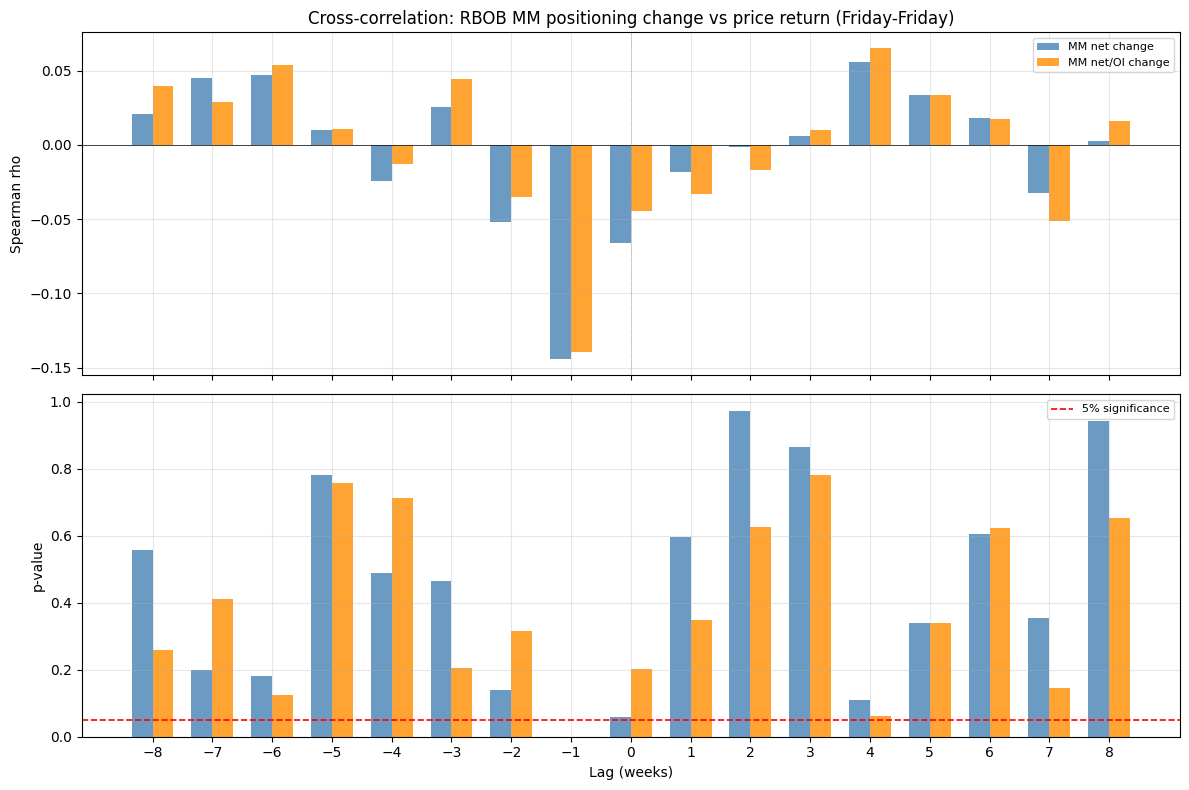

 Lag   rho (raw)       p-val    rho (OI)       p-val
-------------------------------------------------------
  -8     +0.021       5.6e-01     +0.040       2.6e-01
  -7     +0.045       2.0e-01     +0.029       4.1e-01
  -6     +0.047       1.8e-01     +0.054       1.2e-01
  -5     +0.010       7.8e-01     +0.011       7.6e-01
  -4     -0.024       4.9e-01     -0.013       7.1e-01
  -3     +0.026       4.6e-01     +0.045       2.0e-01
  -2     -0.052       1.4e-01     -0.035       3.1e-01
  -1     -0.144 *     3.5e-05     -0.139 *     6.3e-05
   0     -0.066       5.9e-02     -0.045       2.0e-01
   1     -0.019       6.0e-01     -0.033       3.5e-01
   2     -0.001       9.7e-01     -0.017       6.3e-01
   3     +0.006       8.6e-01     +0.010       7.8e-01
   4     +0.056       1.1e-01     +0.065       6.2e-02
   5     +0.034       3.4e-01     +0.034       3.4e-01
   6     +0.018       6.1e-01     +0.017       6.2e-01
   7     -0.032       3.5e-01     -0.051       1.5e-01
   8     +0

In [5]:
MAX_LAG = 8
def compute_ccf(x, y, max_lag):
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

net_vals = df['mm_net_chg'].values
oi_vals = df['mm_net_oi_chg'].values
price_vals = df['price_ret'].values
lags, rhos_raw, pvals_raw = compute_ccf(net_vals, price_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(oi_vals, price_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)
ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue', alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange', alpha=0.8, label='MM net/OI change')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('Cross-correlation: RBOB MM positioning change vs price return (Friday-Friday)')
ax.legend(fontsize=8)
ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue', alpha=0.8)
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}')
print('-' * 55)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}')


## 5. 2-year blocks

In [6]:
df['year'] = df['as_of_date'].dt.year
blocks_2y = [
    ('2010-2011', (2010, 2011)), ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)), ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)), ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)), ('2024-2025', (2024, 2025)),
]
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY: print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))
for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011   100  -0.257  -0.565  -0.036  +0.150  +0.118
   2012-2013   103  +0.221  +0.206  +0.044  -0.157  -0.125
   2014-2015    98  +0.102  -0.108  +0.018  -0.090  +0.014
   2016-2017   102  -0.212  -0.667  -0.175  +0.190  +0.128
   2018-2019   103  -0.131  -0.607  -0.299  -0.032  -0.050
   2020-2021    98  -0.110  +0.055  -0.118  -0.057  +0.078
   2022-2023   102  -0.029  +0.402  +0.116  +0.022  -0.113
   2024-2025   102  -0.002  +0.536  +0.130  -0.169  +0.010
 Full sample   808  -0.052  -0.146  -0.065  -0.021  -0.002


## 5b. CCF by 5-year blocks

Is the lead/lag structure stable across different market regimes,
or is the full-sample CCF dominated by a particular period?

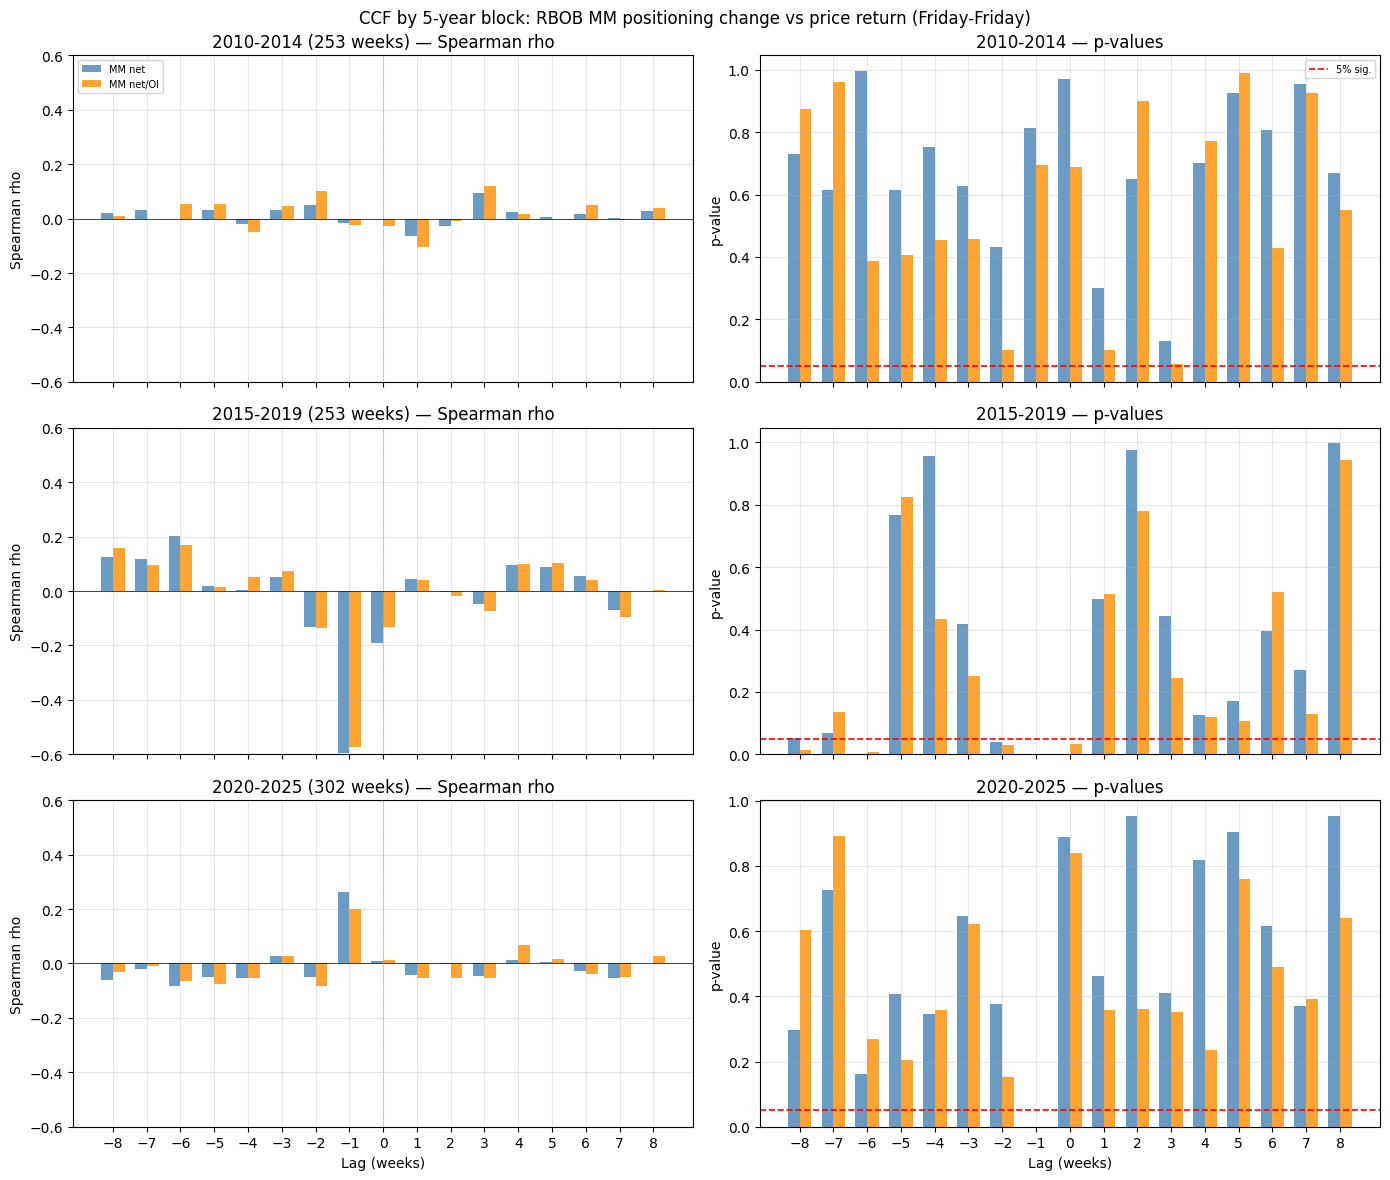

In [7]:
# Define 5-year blocks
blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

fig, axes = plt.subplots(len(blocks_5y), 2, figsize=(14, 4 * len(blocks_5y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_5y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 5-year block: RBOB MM positioning change vs price return (Friday-Friday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   253  +0.050  -0.015  -0.002  -0.066  -0.029
   2015-2019   253  -0.131  -0.594  -0.193  +0.043  -0.002
   2020-2025   302  -0.051  +0.263  +0.008  -0.043  -0.003
 Full sample   808  -0.052  -0.146  -0.065  -0.021  -0.002


## 5c. CCF by 3-year blocks

Finer granularity to see how the lead/lag structure evolves.

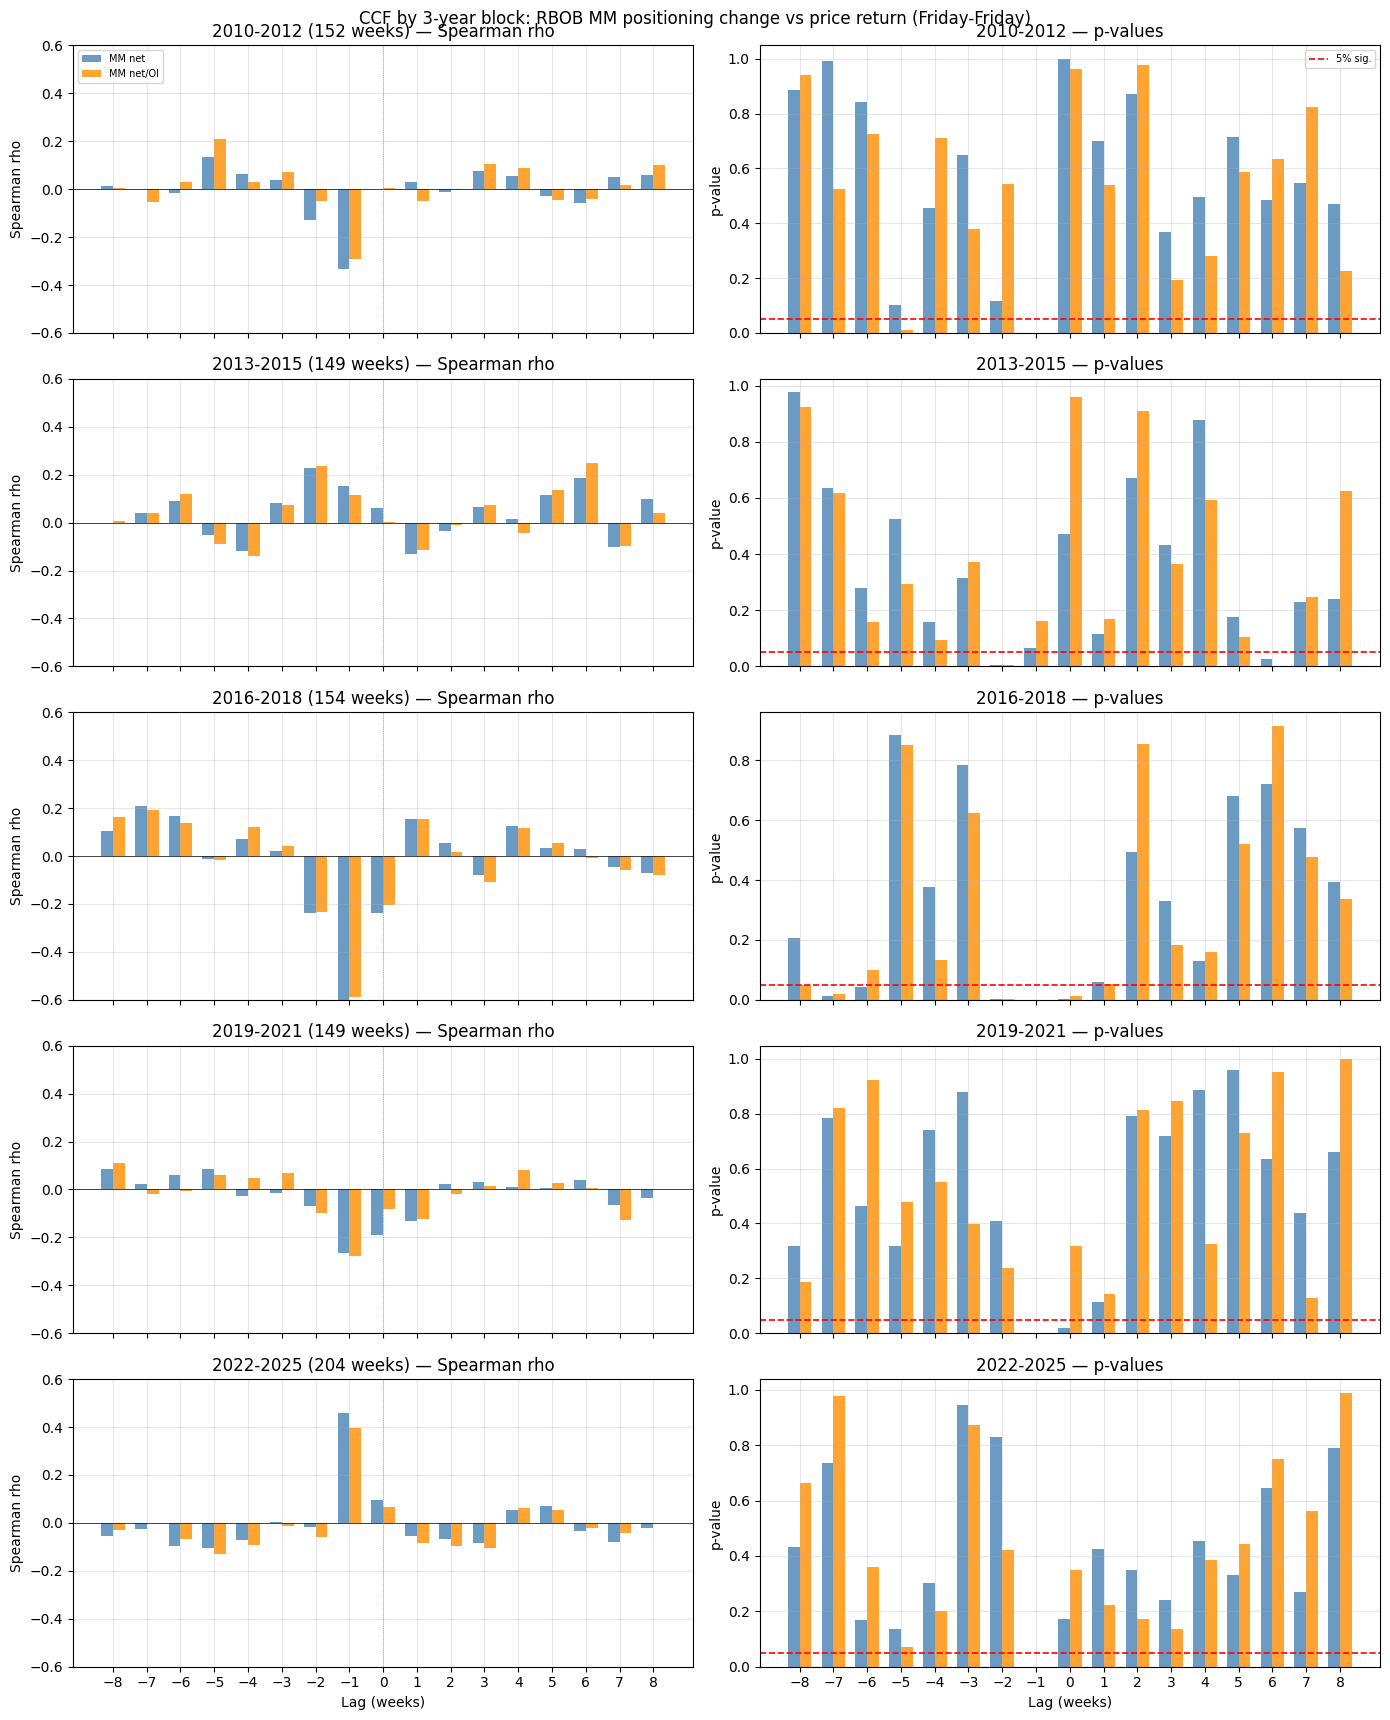

In [9]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

fig, axes = plt.subplots(len(blocks_3y), 2, figsize=(14, 3.5 * len(blocks_3y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_3y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    pr_b = sub['price_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, pr_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, pr_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 3-year block: RBOB MM positioning change vs price return (Friday-Friday)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    pr_b = sub['price_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                pr_b[k:] if k > 0 else pr_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], pr_b[:len(pr_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()

       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   152  -0.128  -0.332  -0.000  +0.032  -0.013
   2013-2015   149  +0.229  +0.151  +0.060  -0.130  -0.035
   2016-2018   154  -0.238  -0.599  -0.240  +0.153  +0.056
   2019-2021   149  -0.069  -0.266  -0.192  -0.130  +0.022
   2022-2025   204  -0.015  +0.459  +0.096  -0.056  -0.066
 Full sample   808  -0.052  -0.146  -0.065  -0.021  -0.002


## 6. Rolling stability of key lags

Are the lead/lag relationships stable over time? Compute the
lag -1, 0, +1 correlations on a rolling 104-week (2-year) window.

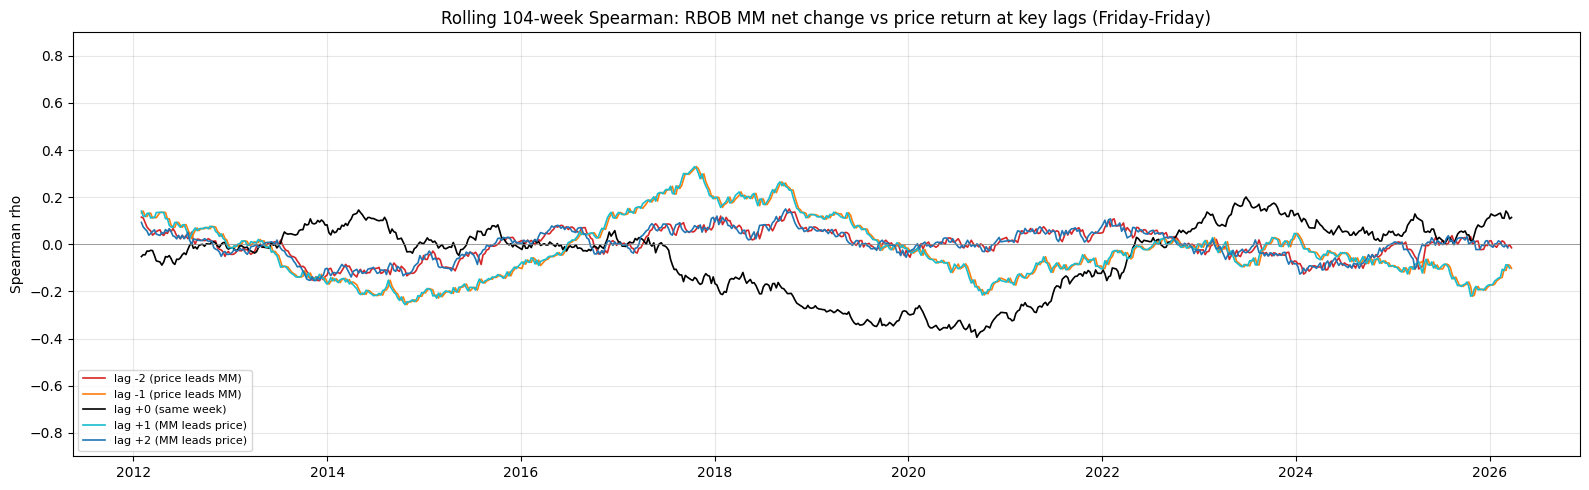

In [11]:
WINDOW = 104  # 2 years
KEY_LAGS = [-2, -1, 0, 1, 2]

mm_vals = df['mm_net_chg'].values
price_vals = df['price_ret'].values

rolling_results = {}
for k in KEY_LAGS:
    mm_s = pd.Series(mm_vals)
    pr_s = pd.Series(price_vals)
    if k >= 0:
        aligned_mm = mm_s.iloc[:len(mm_s)-k] if k > 0 else mm_s
        aligned_pr = pr_s.shift(-k).iloc[:len(pr_s)-k] if k > 0 else pr_s
    else:
        aligned_mm = mm_s.shift(-k)
        aligned_pr = pr_s

    rhos = []
    for i in range(len(aligned_mm)):
        if i < WINDOW:
            rhos.append(np.nan)
            continue
        m_win = aligned_mm.iloc[i-WINDOW:i].values
        p_win = aligned_pr.iloc[i-WINDOW:i].values
        mask = ~(np.isnan(m_win) | np.isnan(p_win))
        if mask.sum() < 20:
            rhos.append(np.nan)
        else:
            rhos.append(sp_stats.spearmanr(m_win[mask], p_win[mask]).statistic)
    rolling_results[k] = rhos[:len(df)]

fig, ax = plt.subplots(figsize=(16, 5))
lag_colors = {-2: 'tab:red', -1: 'tab:orange', 0: 'black', 1: 'tab:cyan', 2: 'tab:blue'}
for k in KEY_LAGS:
    label = f'lag {k:+d}' + (' (price leads MM)' if k < 0 else ' (MM leads price)' if k > 0 else ' (same week)')
    vals = rolling_results[k]
    ax.plot(df['as_of_date'].iloc[:len(vals)], vals,
            label=label, color=lag_colors[k], lw=1.2)

ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman: RBOB MM net change vs price return at key lags (Friday-Friday)')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.9, 0.9)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Cumulative P&L

In [12]:
df['price_chg'] = df['F1_RolledPrice'].diff()
df['pnl'] = df['mm_net'].shift(1) * df['price_chg']
pnl = df.dropna(subset=['pnl']).copy()
pnl['cum_pnl'] = pnl['pnl'].cumsum()
ann = np.sqrt(52)
sr = pnl['pnl'].mean() / pnl['pnl'].std() * ann
total = pnl['pnl'].sum()
print(f'RBOB MM Net Position P&L (raw contracts):')
print(f'  Cumulative P&L: ${total:>14,.0f}')
print(f'  Sharpe Ratio:   {sr:+.2f}')
print(f'  Weeks:          {len(pnl)}')


RBOB MM Net Position P&L (raw contracts):
  Cumulative P&L: $    17,169,786
  Sharpe Ratio:   +0.24
  Weeks:          819


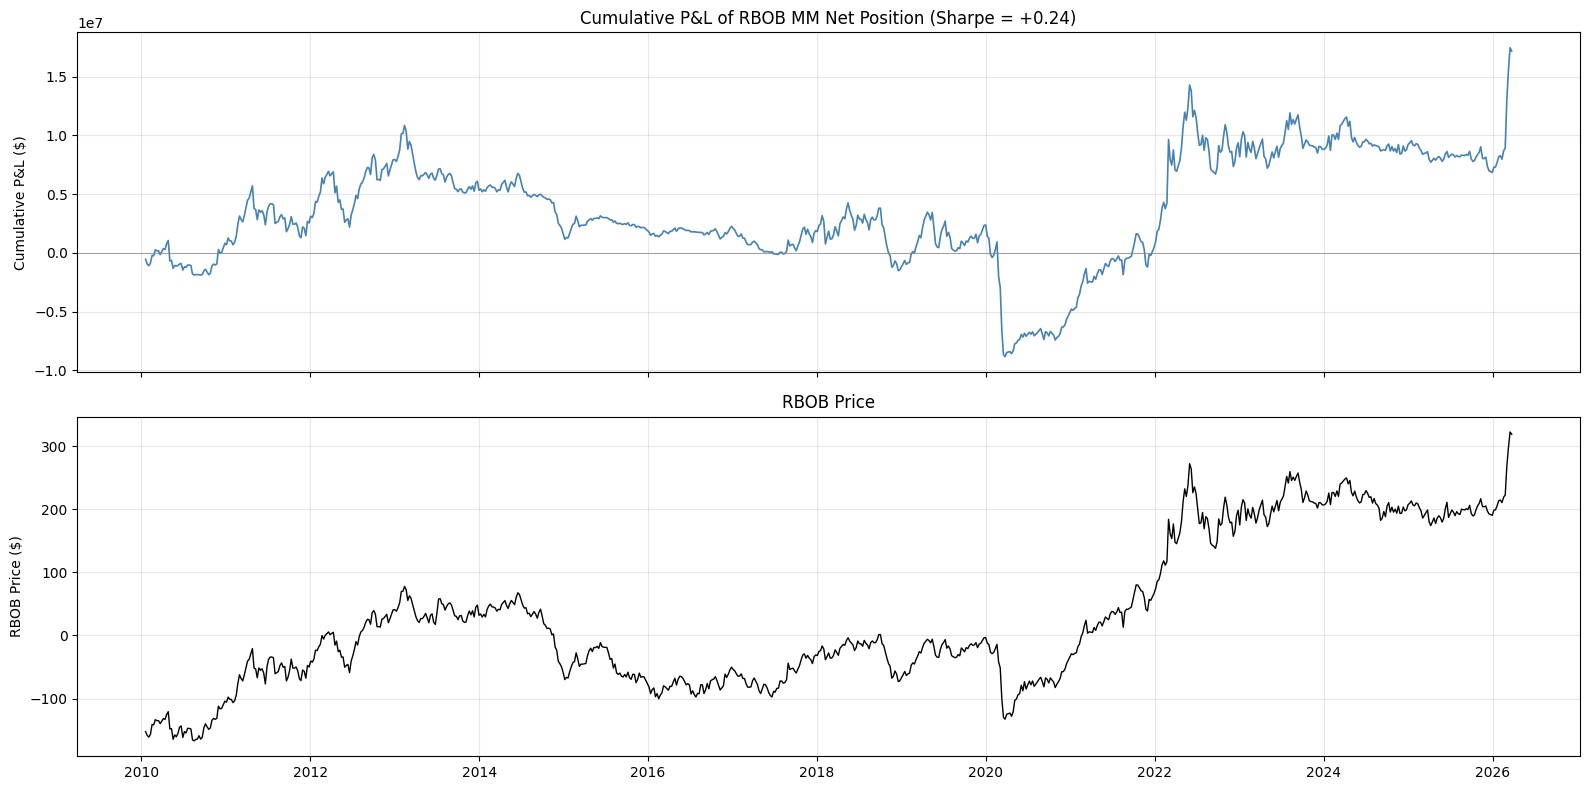

In [13]:
dt_pnl = pd.to_datetime(pnl['as_of_date'])
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax = axes[0]
ax.plot(dt_pnl, pnl['cum_pnl'], color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title(f'Cumulative P&L of RBOB MM Net Position (Sharpe = {sr:+.2f})')
ax = axes[1]
ax.plot(dt_pnl, pnl['F1_RolledPrice'], color='black', lw=1)
ax.set_ylabel('RBOB Price ($)')
ax.set_title('RBOB Price')
plt.tight_layout()
plt.show()


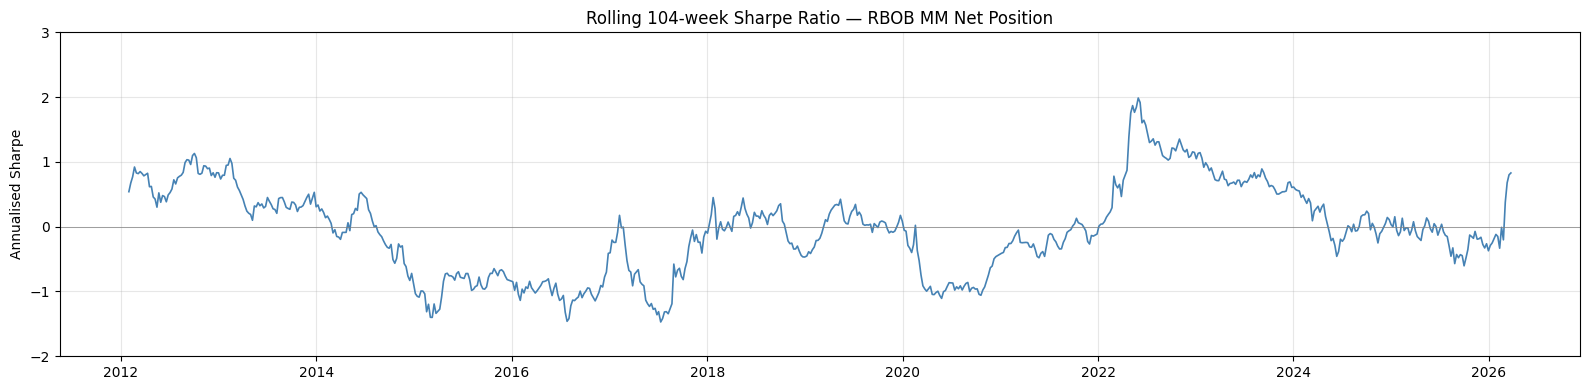

In [14]:
# Rolling 2-year Sharpe
ROLL_W = 104
ann = np.sqrt(52)
roll_sr = pnl['pnl'].rolling(ROLL_W).mean() / pnl['pnl'].rolling(ROLL_W).std() * ann

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(dt_pnl, roll_sr, color='steelblue', lw=1.2)
ax.axhline(0, color='grey', lw=0.5)
ax.set_ylabel('Annualised Sharpe')
ax.set_title(f'Rolling {ROLL_W}-week Sharpe Ratio — RBOB MM Net Position')
ax.set_ylim(-2, 3)
plt.tight_layout()
plt.show()